In [74]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import optuna

import shap


In [27]:
df = pd.read_csv("Maternal Health Risk Data Set.csv")

In [28]:
df.shape

(1014, 7)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [30]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [31]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(562)

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.shape

(452, 7)

In [35]:
df['RiskLevel'].value_counts()

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64

In [36]:
df.drop('DiastolicBP', axis=1, inplace=True)

In [37]:
from sklearn.preprocessing import LabelEncoder

mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel'] = df['RiskLevel'].map(mapping)

In [38]:
df['RiskLevel'].value_counts()

RiskLevel
0    234
2    112
1    106
Name: count, dtype: int64

In [39]:
x = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

In [40]:
print(x.shape)
print(y.shape)

(452, 5)
(452,)


In [41]:
from imblearn.over_sampling import SMOTE

In [42]:
smote = SMOTE(random_state = 42)
X_resampled, Y_resampled = smote.fit_resample(x, y)

In [43]:
print(Y_resampled.value_counts())

RiskLevel
2    234
0    234
1    234
Name: count, dtype: int64


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_resampled, test_size=0.2, random_state=42 )

print(X_train.shape)
print(X_test.shape)

(561, 5)
(141, 5)


In [46]:
df.head()

,Age,SystolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,15.0,98.0,86,2
1,35,140,13.0,98.0,70,2
2,29,90,8.0,100.0,80,2
3,30,140,7.0,98.0,70,2
4,35,120,6.1,98.0,76,0


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

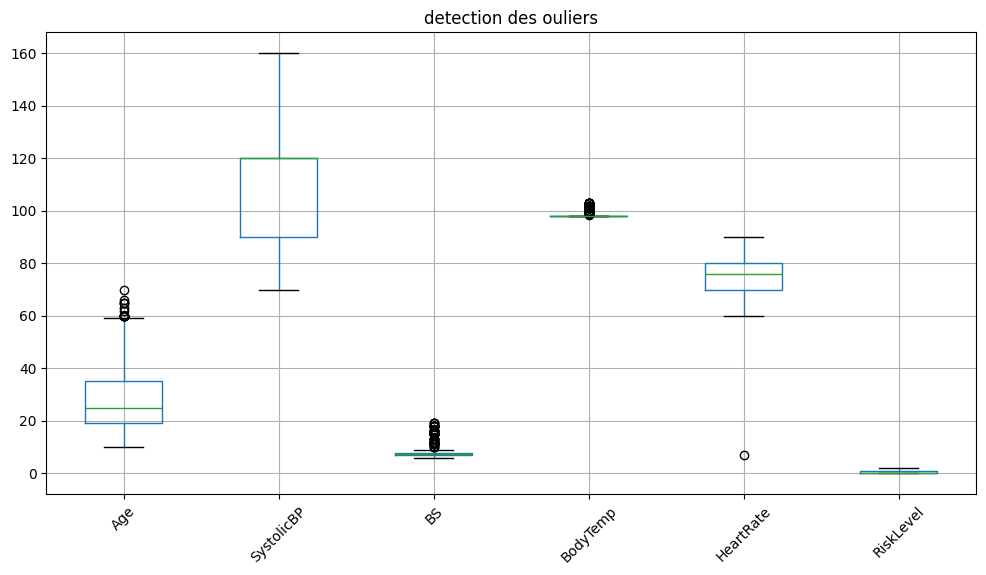

In [48]:
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("detection des ouliers")
plt.xticks(rotation=45)
plt.show

## NOUS POUVONS GARDER LES OUTLIERS ETANT DONNE QU'ILS N'ONT PAS UNE GRANDE DISTANCE  AVEC LES MAX

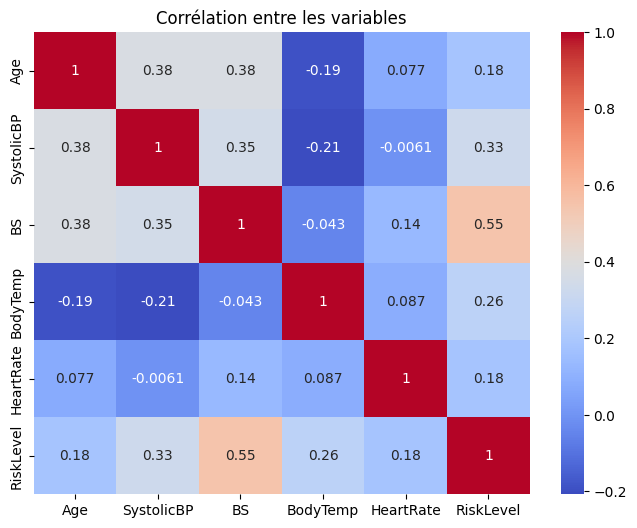

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables")
plt.show()


In [51]:
# Modèle 1 - Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest :", accuracy_score(y_test, y_pred_rf))

Random Forest : 0.7375886524822695


In [52]:
# Modèle 2 - Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting :", accuracy_score(y_test, y_pred_gb))


Gradient Boosting : 0.7730496453900709


In [53]:
# Modèle 3 - Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression :", accuracy_score(y_test, y_pred_lr))


Logistic Regression : 0.5957446808510638


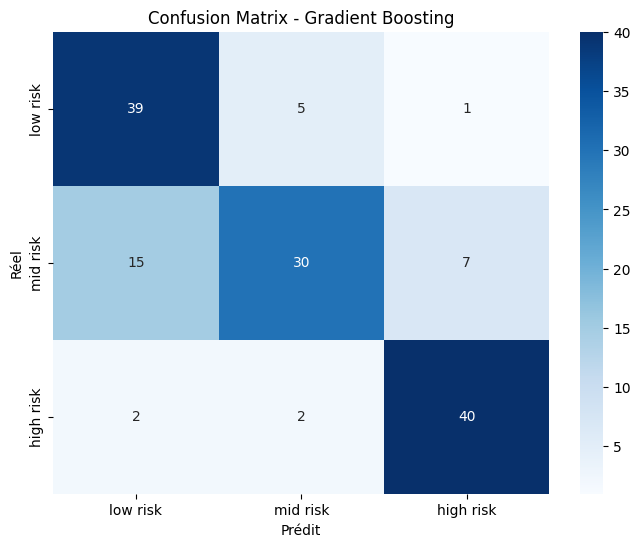

In [55]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low risk', 'mid risk', 'high risk'],
            yticklabels=['low risk', 'mid risk', 'high risk'])
plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()


In [56]:
print(classification_report(y_test, y_pred_gb,
      target_names=['low risk', 'mid risk', 'high risk']))


              precision    recall  f1-score   support

    low risk       0.70      0.87      0.77        45
    mid risk       0.81      0.58      0.67        52
   high risk       0.83      0.91      0.87        44

    accuracy                           0.77       141
   macro avg       0.78      0.78      0.77       141
weighted avg       0.78      0.77      0.77       141



In [67]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
    }
   
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
   
    return accuracy_score(y_test, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Meilleur score :", study.best_value)
print("Meilleurs paramètres :", study.best_params)

[I 2026-03-20 11:51:02,552] A new study created in memory with name: no-name-3b4e522c-c3b3-409f-8b28-9e99f67881c8
[I 2026-03-20 11:51:05,729] Trial 0 finished with value: 0.7659574468085106 and parameters: {'n_estimators': 279, 'max_depth': 5, 'learning_rate': 0.2786950803249428, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.7659574468085106.
[I 2026-03-20 11:51:08,387] Trial 1 finished with value: 0.7304964539007093 and parameters: {'n_estimators': 470, 'max_depth': 3, 'learning_rate': 0.13191968576929328, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.7659574468085106.
[I 2026-03-20 11:51:09,870] Trial 2 finished with value: 0.75177304964539 and parameters: {'n_estimators': 113, 'max_depth': 7, 'learning_rate': 0.05891956717005598, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7659574468085106.
[I 2026-03-20 11:51:13,452] Trial 3 finished with value: 0.7659574468085106 and parameters: {'n_e

Meilleur score : 0.7943262411347518
Meilleurs paramètres : {'n_estimators': 193, 'max_depth': 6, 'learning_rate': 0.05208390326973985, 'min_samples_split': 8, 'min_samples_leaf': 2}


In [70]:
best_model = GradientBoostingClassifier(
    n_estimators= 193, 
    max_depth= 6, 
    learning_rate= 0.05208390326973985, 
    min_samples_split= 8,
    min_samples_leaf= 2,
    random_state= 42
)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)


In [71]:
print("Score optimisé :", accuracy_score(y_test, y_pred_best))

Score optimisé : 0.7943262411347518


In [72]:
print(classification_report(y_test, y_pred_best,
      target_names=['low risk', 'mid risk', 'high risk']))


              precision    recall  f1-score   support

    low risk       0.71      0.80      0.75        45
    mid risk       0.80      0.67      0.73        52
   high risk       0.89      0.93      0.91        44

    accuracy                           0.79       141
   macro avg       0.80      0.80      0.80       141
weighted avg       0.80      0.79      0.79       141



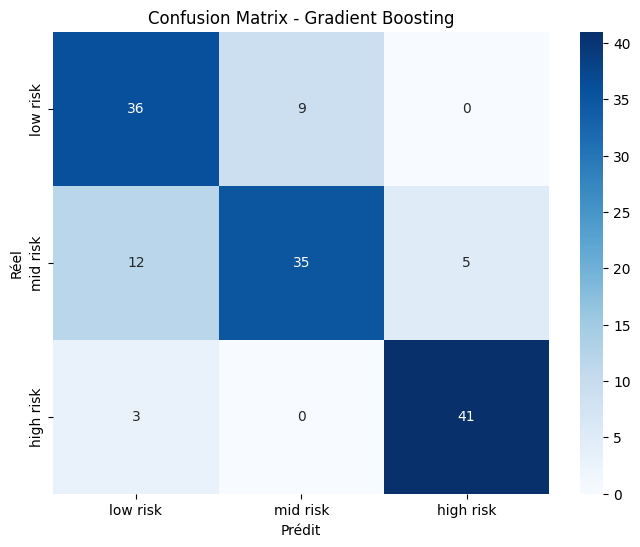

In [73]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low risk', 'mid risk', 'high risk'],
            yticklabels=['low risk', 'mid risk', 'high risk'])
plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()


In [76]:
explainer = shap.KernelExplainer(best_model.predict_proba,
                                  shap.sample(X_train, 100))
shap_values = explainer.shap_values(X_test[:50])


print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

  0%|          | 0/50 [00:00<?, ?it/s]

<class 'numpy.ndarray'>
50
(5, 3)


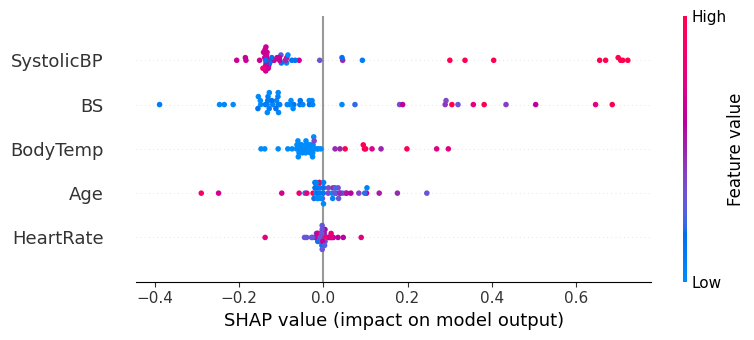

In [78]:
# Extraire high risk (classe 2)
shap_high = shap_values[:, :, 2]

shap.summary_plot(shap_high,
                  X_test[:50],
                  feature_names=list(x.columns))

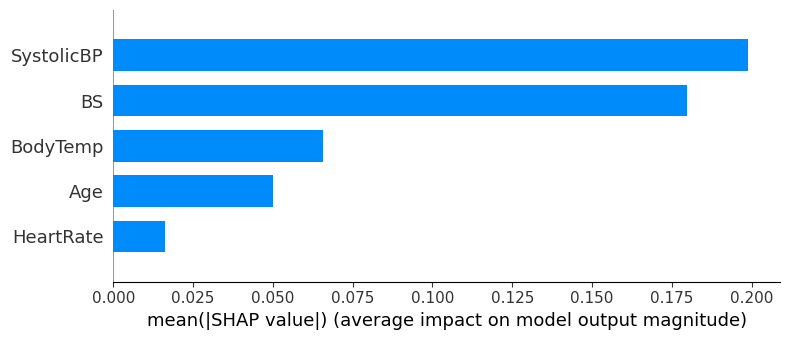

In [80]:
shap.summary_plot(shap_high, X_test[:50],
                  feature_names=list(x.columns),
                  plot_type="bar")

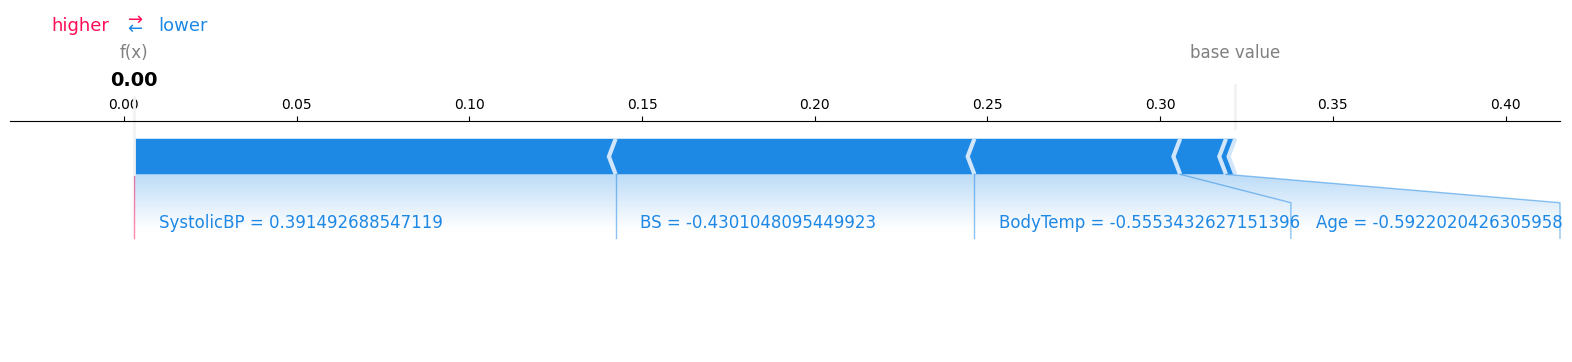

In [82]:
#Force Plot — expliquer UNE patiente
#Pourquoi cette patiente précise est classée High Risk ?
shap.force_plot(explainer.expected_value[2],
                shap_high[0],
                X_test[0],
                feature_names=list(x.columns),
                matplotlib=True)


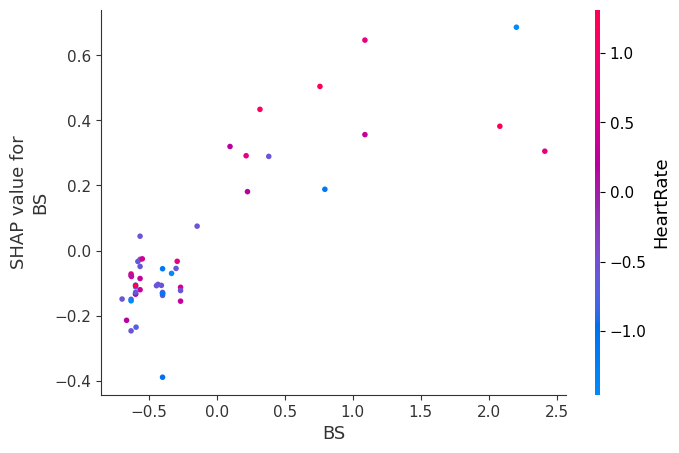

In [84]:
shap.dependence_plot("BS", shap_high,
                     X_test[:50],
                     feature_names=list(x.columns))

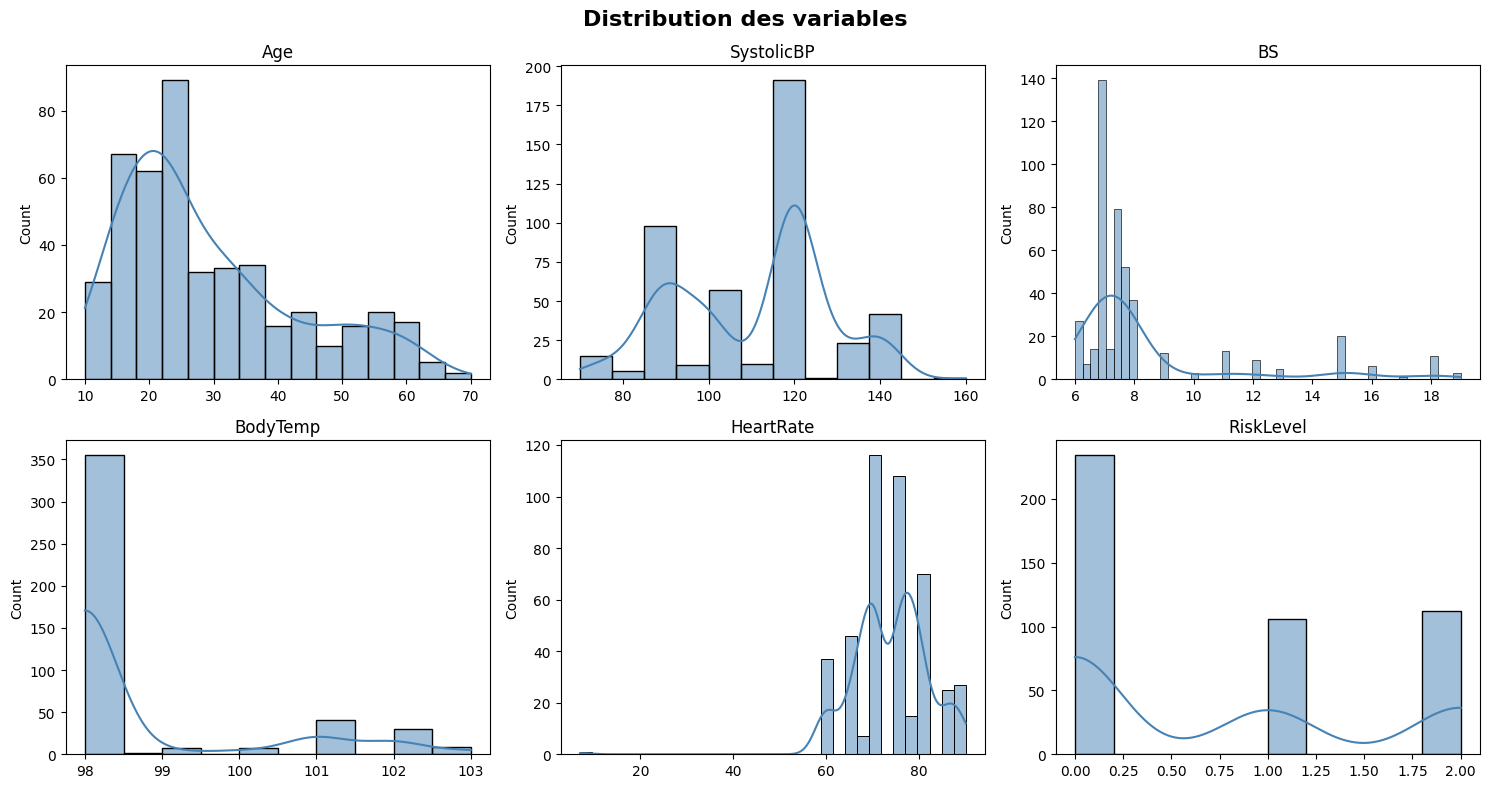

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribution des variables", fontsize=16, fontweight='bold')

cols = ['Age', 'SystolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_13124\60371368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='RiskLevel', y='BS', data=df,


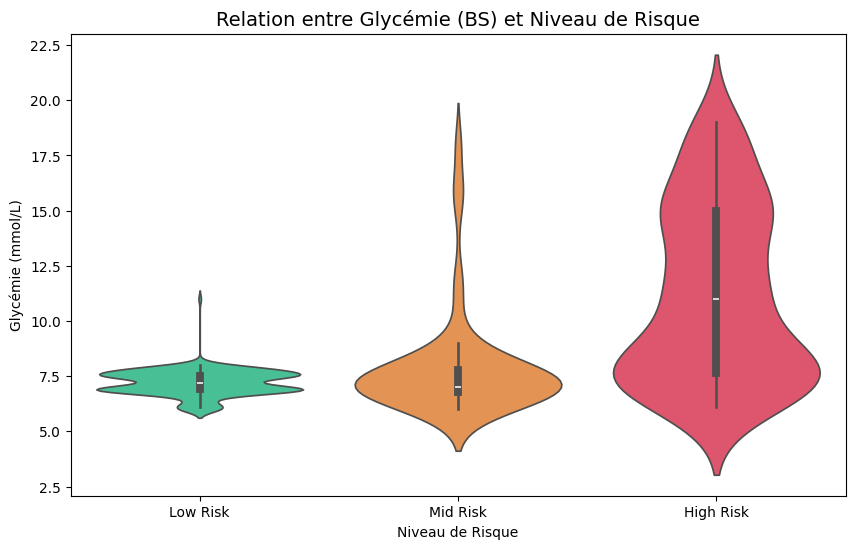

In [88]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='RiskLevel', y='BS', data=df,
               palette=['#34d399', '#fb923c', '#f43f5e'])

plt.xticks([0, 1, 2], ['Low Risk', 'Mid Risk', 'High Risk'])
plt.title("Relation entre Glycémie (BS) et Niveau de Risque", fontsize=14)
plt.xlabel("Niveau de Risque")
plt.ylabel("Glycémie (mmol/L)")
plt.show()

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_13124\1150849818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y='Age', data=df,


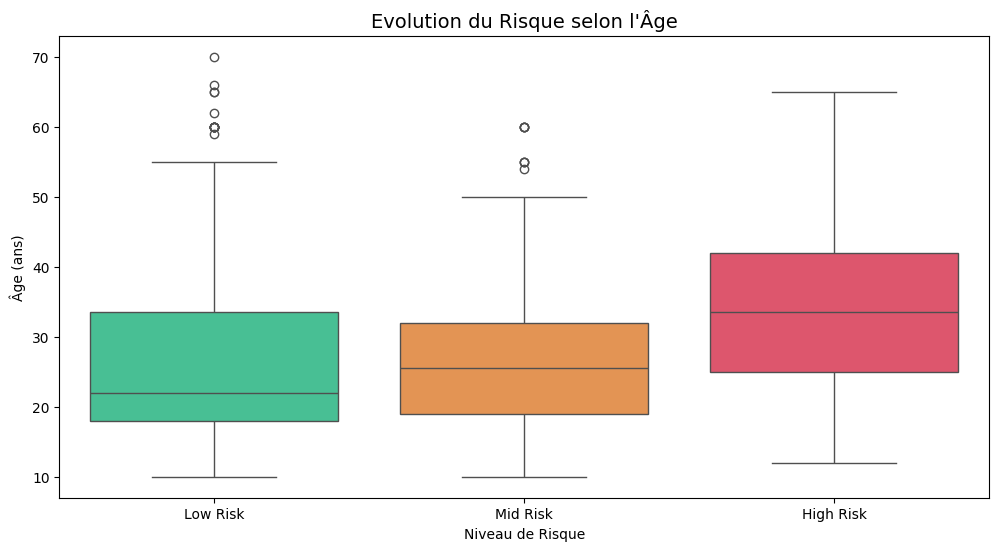

In [89]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='RiskLevel', y='Age', data=df,
            palette=['#34d399', '#fb923c', '#f43f5e'])

plt.xticks([0, 1, 2], ['Low Risk', 'Mid Risk', 'High Risk'])
plt.title("Evolution du Risque selon l'Âge", fontsize=14)
plt.xlabel("Niveau de Risque")
plt.ylabel("Âge (ans)")
plt.show()

## nous remarqouns ici que effectivement le risque augmente avec l'age

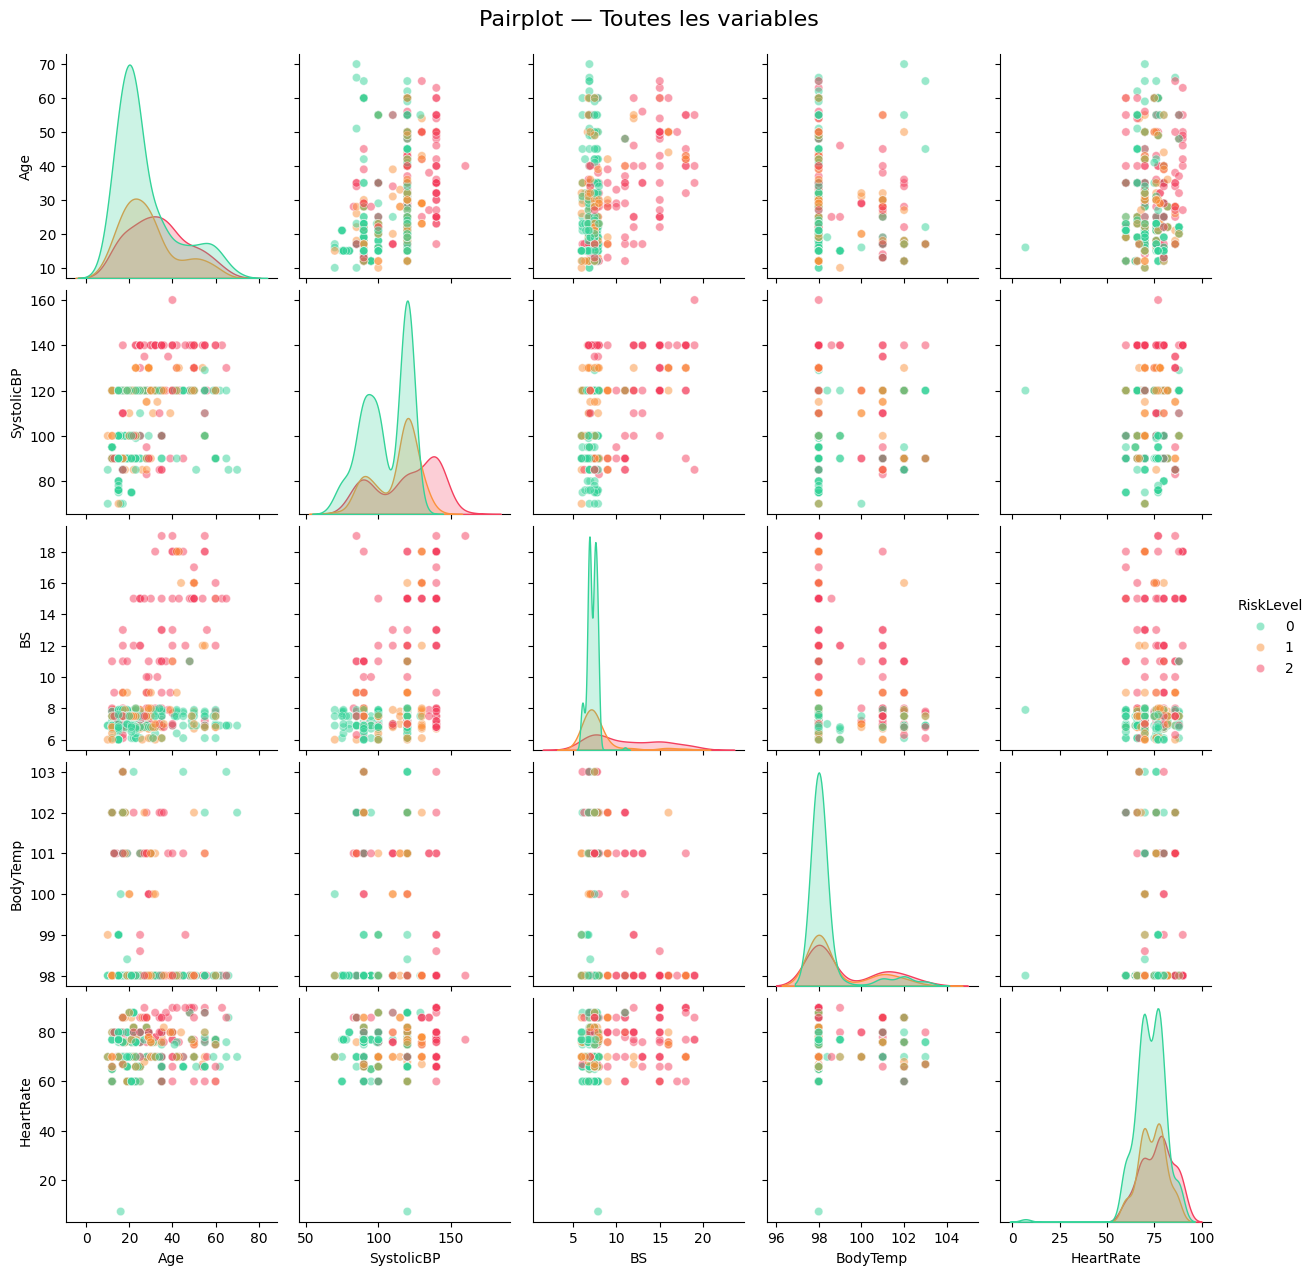

In [92]:
sns.pairplot(df, hue='RiskLevel',
             palette={0: '#34d399', 1: '#fb923c', 2: '#f43f5e'},
             plot_kws={'alpha': 0.5},
             diag_kind='kde')

plt.suptitle("Pairplot — Toutes les variables",
             fontsize=16, y=1.02)
plt.show()

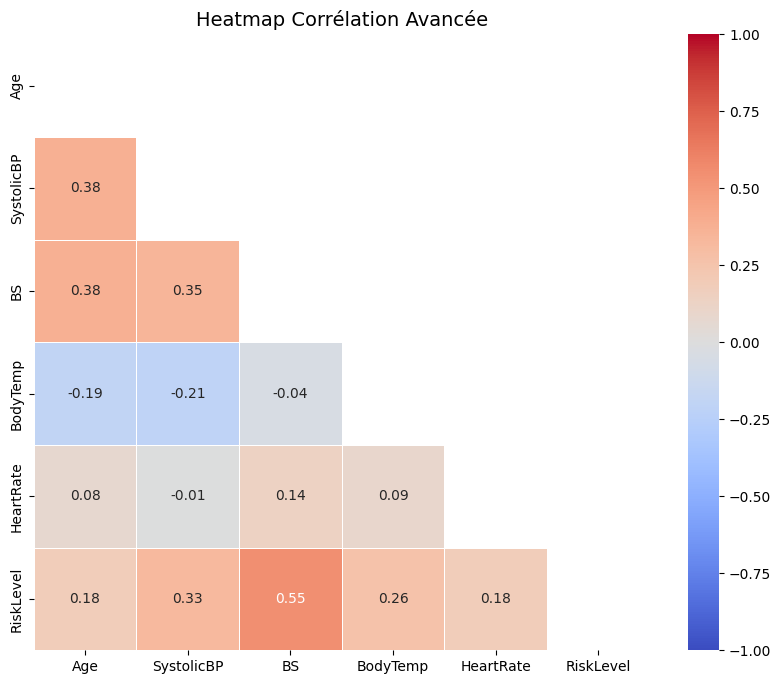

In [93]:
plt.figure(figsize=(10, 8))

mask = np.zeros_like(df.corr())
mask[np.triu_indices_from(mask)] = True

sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            mask=mask,
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True)

plt.title("Heatmap Corrélation Avancée", fontsize=14)
plt.show()

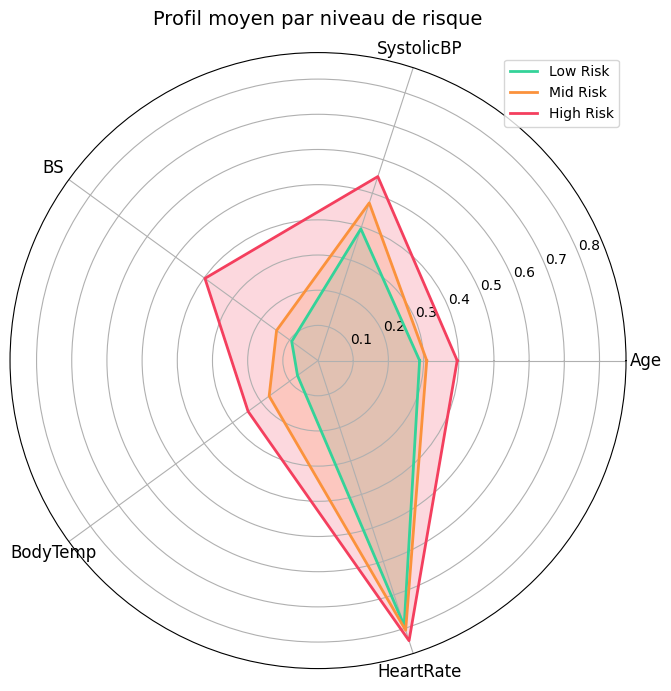

In [96]:

from sklearn.preprocessing import MinMaxScaler

categories = ['Age', 'SystolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Normaliser chaque variable entre 0 et 1 séparément
scaler_radar = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler_radar.fit_transform(df[categories]),
    columns=categories
)
df_scaled['RiskLevel'] = df['RiskLevel'].values

# Moyennes par classe
low  = df_scaled[df_scaled['RiskLevel']==0][categories].mean().values
mid  = df_scaled[df_scaled['RiskLevel']==1][categories].mean().values
high = df_scaled[df_scaled['RiskLevel']==2][categories].mean().values

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for values, color, label in zip(
    [low, mid, high],
    ['#34d399', '#fb923c', '#f43f5e'],
    ['Low Risk', 'Mid Risk', 'High Risk']
):
    vals = values.tolist() + values[:1].tolist()
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title("Profil moyen par niveau de risque", fontsize=14, pad=20)
ax.legend(loc='upper right')
plt.show()



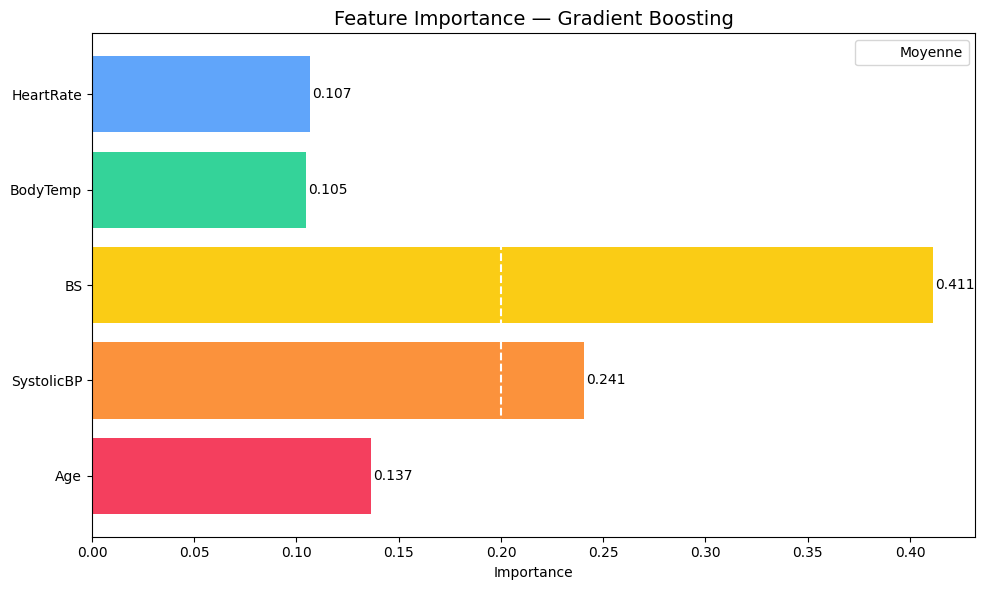

In [98]:
importances = best_model.feature_importances_
features = x.columns

plt.figure(figsize=(10, 6))
bars = plt.barh(features, importances,
                color=['#f43f5e','#fb923c','#facc15','#34d399','#60a5fa'])

plt.xlabel("Importance")
plt.title("Feature Importance — Gradient Boosting", fontsize=14)
plt.axvline(x=importances.mean(), color='white',
            linestyle='--', label='Moyenne')
plt.legend()

for bar, val in zip(bars, importances):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [99]:
import pickle

# Sauvegarder le modèle
with open("maternal_health_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Sauvegarder le scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Modèle et scaler sauvegardés !")

✅ Modèle et scaler sauvegardés !
